# Gold Bus Route: Exploratory Data Analysis

Explores GT Gold bus route data from March 4-6, 2026. Goals:

1. **Understand the dataset**: shape, coverage, data quality
2. **Characterize collection patterns**: snapshot frequency, temporal gaps
3. **Analyze delay behavior**: speed/ETA distributions by vehicle, stop, hour
4. **Assess ETA prediction stability**: how estimates shift as a bus approaches
5. **Propose a model**: target variable, architecture, and feature set

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

## 1. Load and prepare data

In [2]:
DATA_DIR = Path("../bus_data")
csv_files = sorted(DATA_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR.resolve()}")

print(f"Found {len(csv_files)} files:")
for f in csv_files:
    print(f"  {f.name}")

Found 3 files:
  gt_gold_bus_data_2026-03-04.csv
  gt_gold_bus_data_2026-03-05.csv
  gt_gold_bus_data_2026-03-06.csv


In [3]:
# Load and concatenate all CSV files
frames = []
for csv_path in csv_files:
    df_part = pd.read_csv(csv_path)
    df_part["source_file"] = csv_path.name
    frames.append(df_part)

raw = pd.concat(frames, ignore_index=True)

# Parse datetime columns
for col in ["snapshot_time", "estimated_time_arrival"]:
    raw[col] = pd.to_datetime(raw[col], errors="coerce")

print(f"Raw rows: {len(raw):,}")
print(f"Duplicate rows: {raw.duplicated().sum():,}")

# Drop exact duplicates
df = raw.drop_duplicates().reset_index(drop=True)
print(f"Rows after dedup: {len(df):,}")

# Derived columns
df["eta_minutes"] = (df["estimated_time_arrival"] - df["snapshot_time"]).dt.total_seconds() / 60
df["snapshot_date"] = df["snapshot_time"].dt.date
df["snapshot_hour"] = df["snapshot_time"].dt.hour

df.head(3)

Raw rows: 63,566
Duplicate rows: 2,600
Rows after dedup: 60,966


,snapshot_time,vehicle_id,route_id,route_stop_id,vehicle_lat,vehicle_lon,vehicle_speed,estimated_time_arrival,source_file,eta_minutes,snapshot_date,snapshot_hour
0,2026-03-04 18:05:50.905776,33,29,419.0,33.777097,-84.395484,0.0,2026-03-04 18:29:31.905776,gt_gold_bus_data_2026-03-04.csv,23.683333,2026-03-04,18
1,2026-03-04 18:05:50.905776,33,29,420.0,33.777097,-84.395484,0.0,2026-03-04 18:33:19.905776,gt_gold_bus_data_2026-03-04.csv,27.483333,2026-03-04,18
2,2026-03-04 18:05:50.905776,33,29,407.0,33.777097,-84.395484,0.0,2026-03-04 18:34:47.905776,gt_gold_bus_data_2026-03-04.csv,28.950000,2026-03-04,18


## 2. Dataset overview

In [4]:
print(f"Rows:       {len(df):,}")
print(f"Columns:    {df.shape[1]}")
print(f"Date range: {df['snapshot_time'].min()} → {df['snapshot_time'].max()}")
print(f"Vehicles:   {df['vehicle_id'].nunique()}")
print(f"Stops:      {df['route_stop_id'].nunique()}")
print(f"Route(s):   {df['route_id'].unique().tolist()}")
print()
df.dtypes

Rows:       60,966
Columns:    12
Date range: 2026-03-04 18:05:50.905776 → 2026-03-06 09:43:44.587944
Vehicles:   7
Stops:      21
Route(s):   [29]



snapshot_time             datetime64[us]
vehicle_id                         int64
route_id                           int64
route_stop_id                    float64
vehicle_lat                      float64
vehicle_lon                      float64
vehicle_speed                    float64
estimated_time_arrival    datetime64[us]
source_file                          str
eta_minutes                      float64
snapshot_date                     object
snapshot_hour                      int32
dtype: object

### Missing values

Missing ETAs likely mean the bus was not en route to that stop (e.g., at a stop or out of service).

In [5]:
missing = (
    df.isna()
    .sum()
    .rename("missing")
    .to_frame()
    .assign(pct=lambda x: (x["missing"] / len(df) * 100).round(2))
    .query("missing > 0")
    .sort_values("pct", ascending=False)
)
missing

,missing,pct
estimated_time_arrival,639,1.05
eta_minutes,639,1.05
route_stop_id,3,0.00


In [6]:
# Where are missing ETAs concentrated?
missing_eta = df[df["estimated_time_arrival"].isna()]

print("Missing ETAs by vehicle:")
print(missing_eta["vehicle_id"].value_counts().to_string())
print()
print("Missing ETAs by hour:")
print(missing_eta["snapshot_hour"].value_counts().sort_index().to_string())
print()
print("Missing ETAs by stop:")
print(missing_eta["route_stop_id"].value_counts().sort_index().to_string())

Missing ETAs by vehicle:
vehicle_id
38    208
34    123
33    116
37    115
41     65
10     12

Missing ETAs by hour:
snapshot_hour
6       5
7      10
8      25
9      31
16     81
17    113
18    162
19     86
20    106
21      9
22     11

Missing ETAs by stop:
route_stop_id
396.0     69
397.0     38
398.0     29
399.0     10
400.0     24
401.0     41
402.0      5
404.0     48
407.0     29
408.0     14
409.0      7
410.0     12
411.0      9
412.0     13
413.0     24
415.0     31
416.0     10
417.0     24
419.0    176
420.0      8
421.0     15


### Per-file coverage

Each file covers a partial day. No overnight or early-morning data on most days.

In [7]:
file_summary = (
    df.groupby("source_file")
    .agg(
        rows=("source_file", "size"),
        vehicles=("vehicle_id", "nunique"),
        stops=("route_stop_id", "nunique"),
        start=("snapshot_time", "min"),
        end=("snapshot_time", "max"),
    )
    .sort_index()
)
file_summary["duration_hrs"] = (
    (file_summary["end"] - file_summary["start"]).dt.total_seconds() / 3600
).round(1)

file_summary

,rows,vehicles,stops,start,end,duration_hrs
source_file,,,,,,
gt_gold_bus_data_2026-03-04.csv,13443,5,21,2026-03-04 18:05:50.905776,2026-03-04 21:01:00.165264,2.9
gt_gold_bus_data_2026-03-05.csv,39585,5,21,2026-03-05 16:05:10.318212,2026-03-05 22:57:15.304549,6.9
gt_gold_bus_data_2026-03-06.csv,7938,4,21,2026-03-06 06:08:06.591427,2026-03-06 09:43:44.587944,3.6


## 3. Snapshot frequency and temporal coverage

Irregular polling creates artifacts in delay estimates, so we need to understand the collection cadence.

Snapshot gap (seconds), per vehicle, consecutive rows:
count    60959.0
mean         8.9
std        676.5
min          0.0
25%          0.0
50%          0.0
75%          0.0
max      86659.3


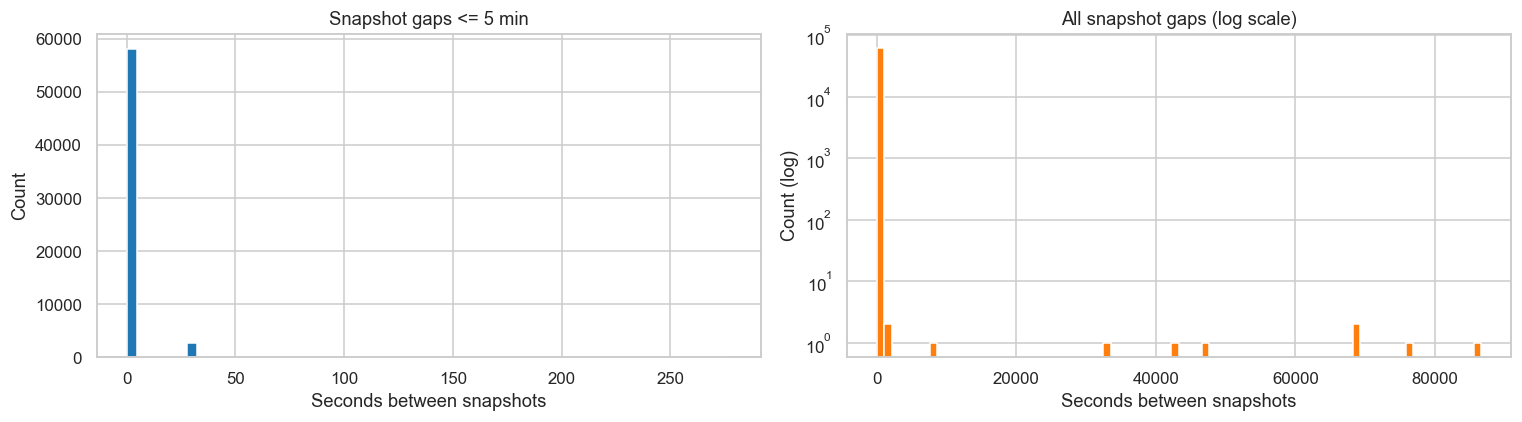

In [8]:
# Time between consecutive snapshots per vehicle
df_sorted = df.sort_values(["vehicle_id", "snapshot_time"])
df_sorted["prev_snapshot"] = df_sorted.groupby("vehicle_id")["snapshot_time"].shift(1)
df_sorted["snapshot_gap_sec"] = (
    (df_sorted["snapshot_time"] - df_sorted["prev_snapshot"]).dt.total_seconds()
)

gap = df_sorted["snapshot_gap_sec"].dropna()
print("Snapshot gap (seconds), per vehicle, consecutive rows:")
print(gap.describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(gap[gap <= 300], bins=60, color="#1f77b4", edgecolor="white")
axes[0].set_title("Snapshot gaps <= 5 min")
axes[0].set_xlabel("Seconds between snapshots")
axes[0].set_ylabel("Count")

axes[1].hist(gap, bins=80, color="#ff7f0e", edgecolor="white", log=True)
axes[1].set_title("All snapshot gaps (log scale)")
axes[1].set_xlabel("Seconds between snapshots")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()

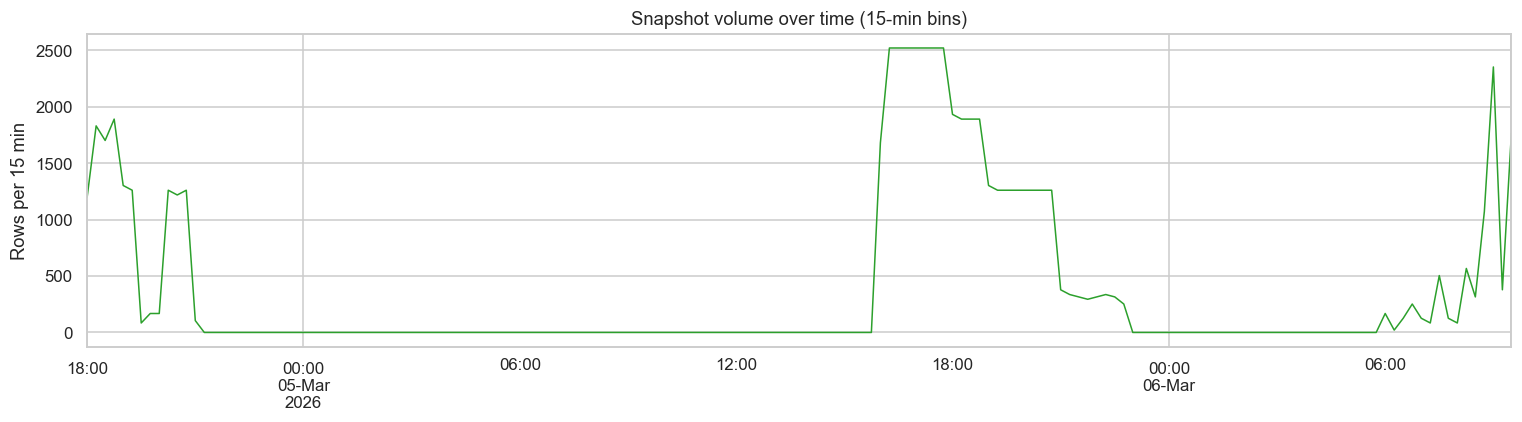

In [9]:
# Snapshot volume over time (reveals collection gaps)
snapshot_counts = (
    df.set_index("snapshot_time")
    .resample("15min")
    .size()
    .rename("snapshots")
)

fig, ax = plt.subplots(figsize=(14, 4))
snapshot_counts.plot(ax=ax, color="#2ca02c", linewidth=1)
ax.set_title("Snapshot volume over time (15-min bins)")
ax.set_xlabel("")
ax.set_ylabel("Rows per 15 min")
plt.tight_layout()

## 4. Speed and ETA distributions

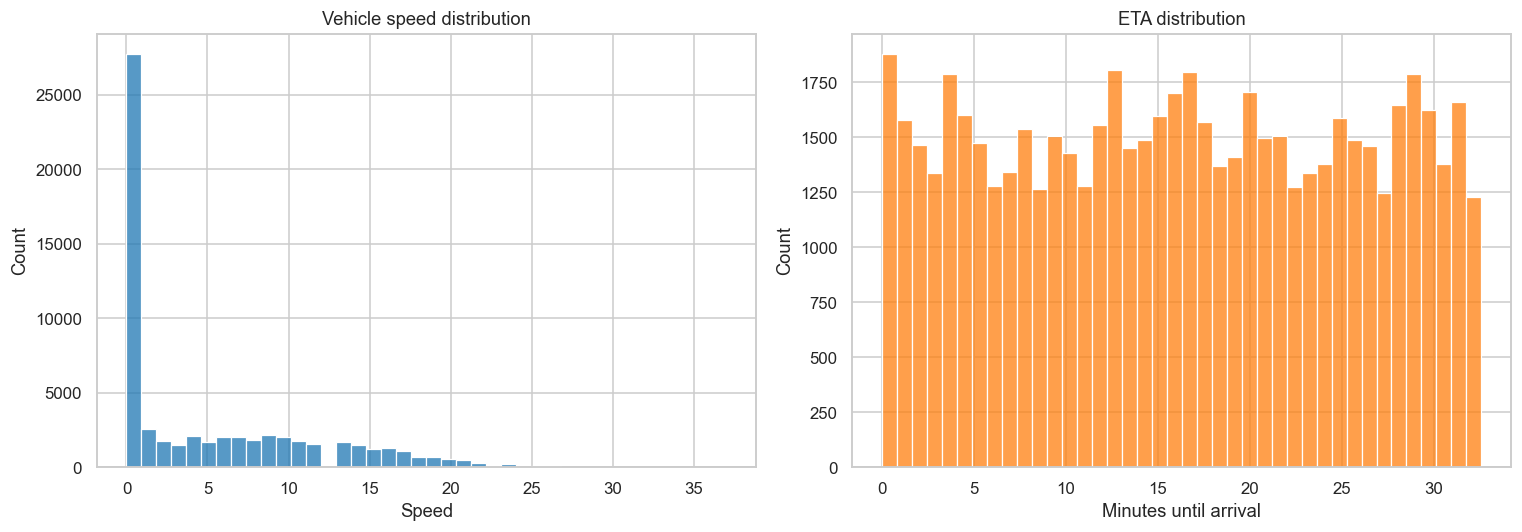

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["vehicle_speed"].dropna(), bins=40, ax=axes[0], color="#1f77b4")
axes[0].set_title("Vehicle speed distribution")
axes[0].set_xlabel("Speed")

sns.histplot(df["eta_minutes"].dropna(), bins=40, ax=axes[1], color="#ff7f0e")
axes[1].set_title("ETA distribution")
axes[1].set_xlabel("Minutes until arrival")

plt.tight_layout()

### Per-vehicle breakdown

Are some buses consistently slower or producing more missing ETAs?

In [11]:
vehicle_stats = (
    df.groupby("vehicle_id")
    .agg(
        rows=("vehicle_id", "size"),
        missing_eta=("eta_minutes", lambda x: x.isna().sum()),
        avg_speed=("vehicle_speed", "mean"),
        median_speed=("vehicle_speed", "median"),
        avg_eta_min=("eta_minutes", "mean"),
        median_eta_min=("eta_minutes", "median"),
    )
    .round(2)
)
vehicle_stats["missing_eta_pct"] = (vehicle_stats["missing_eta"] / vehicle_stats["rows"] * 100).round(1)
vehicle_stats

,rows,missing_eta,avg_speed,median_speed,avg_eta_min,median_eta_min,missing_eta_pct
vehicle_id,,,,,,,
9,21,0,7.00,7.0,18.13,17.02,0.0
10,1974,12,4.21,0.0,16.06,16.67,0.6
33,10921,116,5.17,1.0,16.27,16.28,1.1
34,11740,123,5.77,3.0,16.17,16.17,1.0
37,9429,115,5.53,3.0,16.37,16.25,1.2
38,19573,208,5.06,2.0,16.24,16.28,1.1
41,7308,65,4.61,1.0,15.91,16.08,0.9


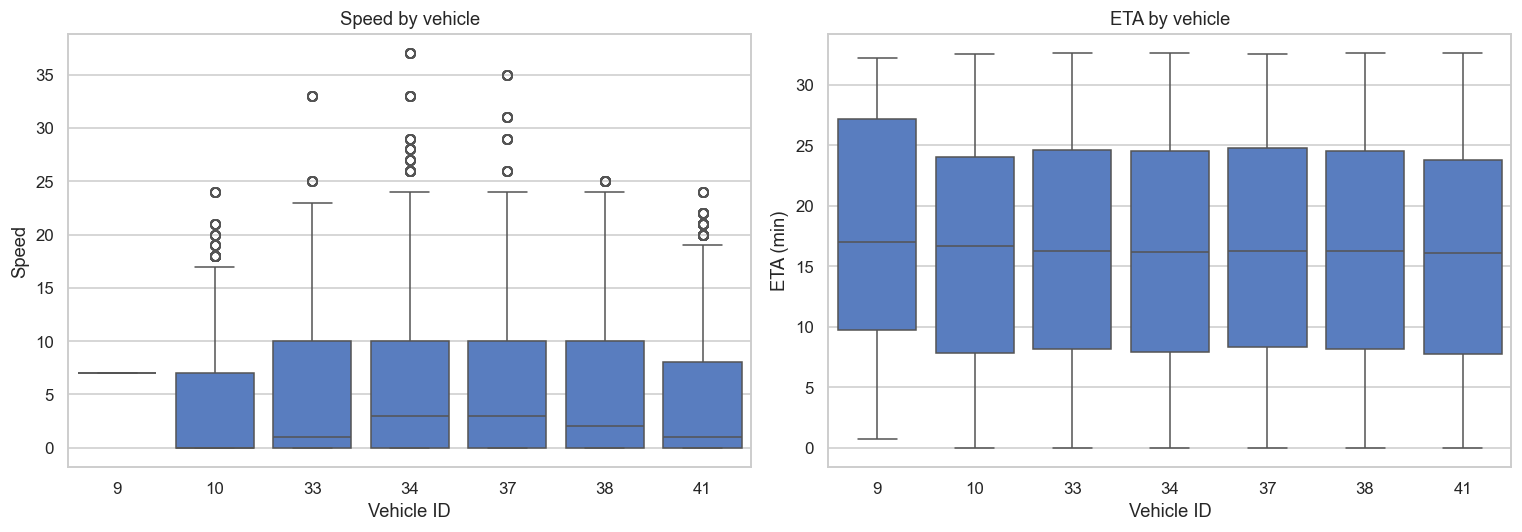

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="vehicle_id", y="vehicle_speed", ax=axes[0])
axes[0].set_title("Speed by vehicle")
axes[0].set_xlabel("Vehicle ID")
axes[0].set_ylabel("Speed")

sns.boxplot(data=df.dropna(subset=["eta_minutes"]), x="vehicle_id", y="eta_minutes", ax=axes[1])
axes[1].set_title("ETA by vehicle")
axes[1].set_xlabel("Vehicle ID")
axes[1].set_ylabel("ETA (min)")

plt.tight_layout()

## 5. Per-stop analysis

Which stops have the longest average wait and the most variable ETAs?

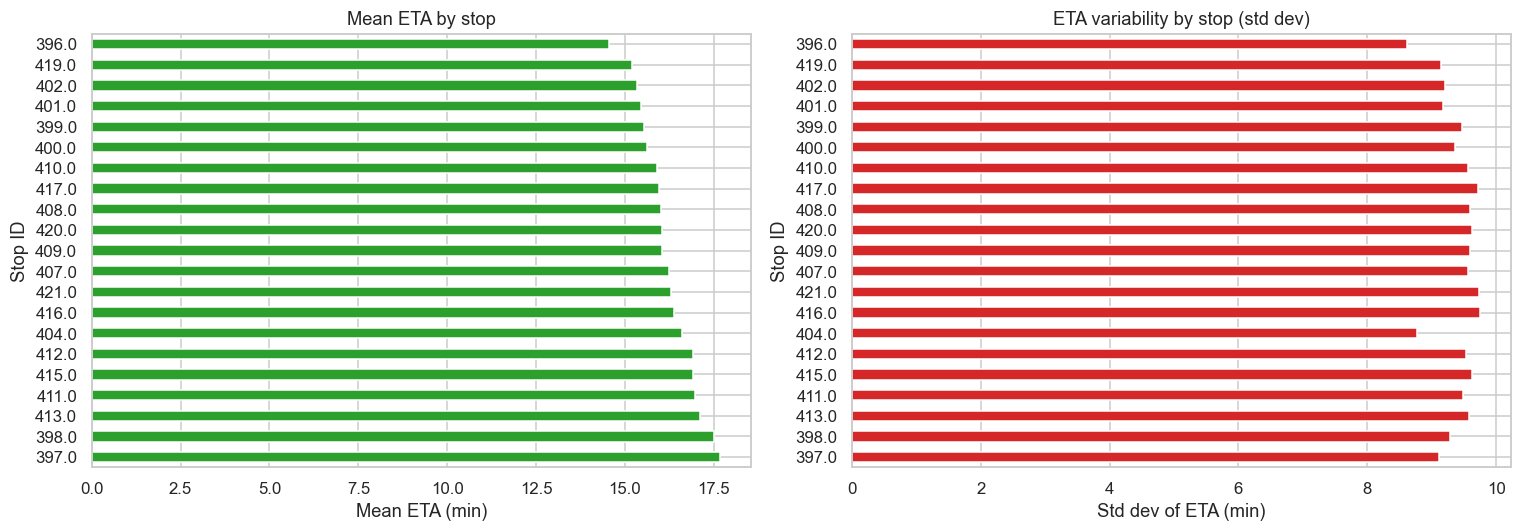

In [13]:
stop_stats = (
    df.dropna(subset=["route_stop_id", "eta_minutes"])
    .groupby("route_stop_id")
    .agg(
        rows=("eta_minutes", "size"),
        mean_eta=("eta_minutes", "mean"),
        median_eta=("eta_minutes", "median"),
        std_eta=("eta_minutes", "std"),
        mean_speed=("vehicle_speed", "mean"),
    )
    .round(2)
    .sort_values("mean_eta", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stop_stats["mean_eta"].plot(kind="barh", ax=axes[0], color="#2ca02c")
axes[0].set_title("Mean ETA by stop")
axes[0].set_xlabel("Mean ETA (min)")
axes[0].set_ylabel("Stop ID")

stop_stats["std_eta"].plot(kind="barh", ax=axes[1], color="#d62728")
axes[1].set_title("ETA variability by stop (std dev)")
axes[1].set_xlabel("Std dev of ETA (min)")
axes[1].set_ylabel("Stop ID")

plt.tight_layout()

## 6. Time-of-day patterns

Speed and ETA by hour to surface rush-hour slowdowns and congestion windows.

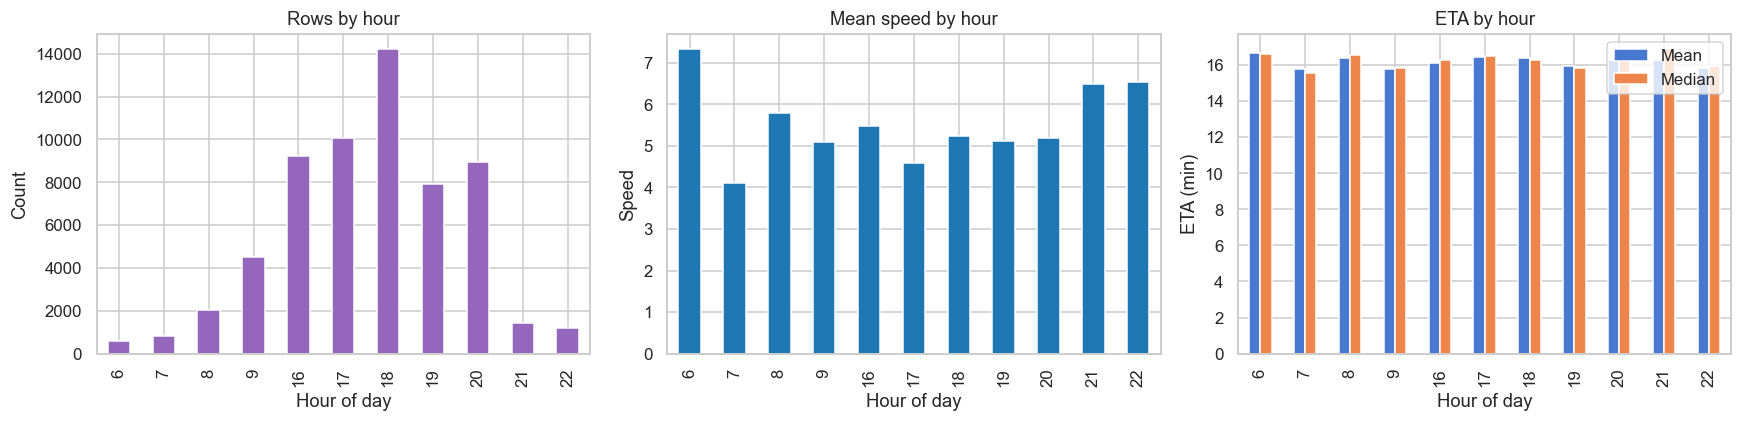

In [14]:
hourly = (
    df.groupby("snapshot_hour")
    .agg(
        rows=("snapshot_hour", "size"),
        mean_speed=("vehicle_speed", "mean"),
        mean_eta=("eta_minutes", "mean"),
        median_eta=("eta_minutes", "median"),
    )
    .round(2)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

hourly["rows"].plot(kind="bar", ax=axes[0], color="#9467bd")
axes[0].set_title("Rows by hour")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Count")

hourly["mean_speed"].plot(kind="bar", ax=axes[1], color="#1f77b4")
axes[1].set_title("Mean speed by hour")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Speed")

hourly[["mean_eta", "median_eta"]].plot(kind="bar", ax=axes[2])
axes[2].set_title("ETA by hour")
axes[2].set_xlabel("Hour of day")
axes[2].set_ylabel("ETA (min)")
axes[2].legend(["Mean", "Median"])

plt.tight_layout()

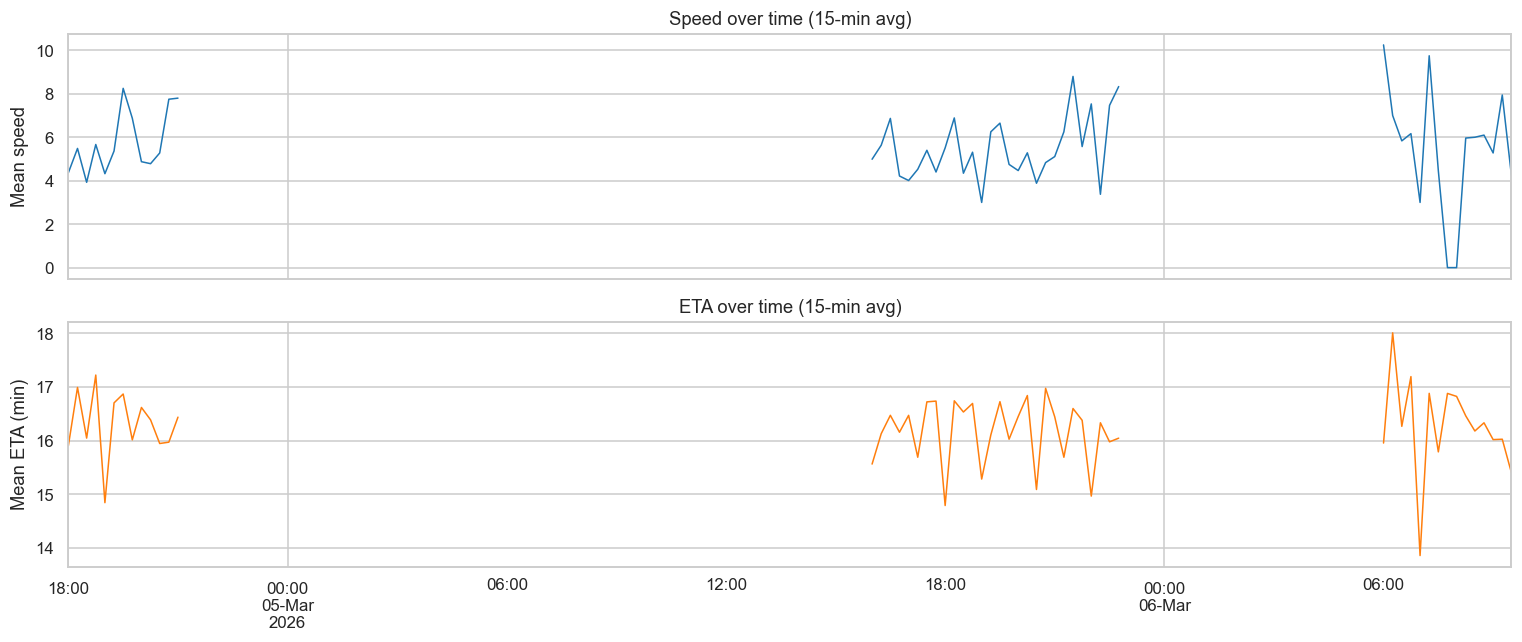

In [15]:
# Time-series: speed and ETA averaged in 15-min bins across all vehicles
ts = df.set_index("snapshot_time").resample("15min").agg(
    mean_speed=("vehicle_speed", "mean"),
    mean_eta=("eta_minutes", "mean"),
)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ts["mean_speed"].plot(ax=axes[0], color="#1f77b4", linewidth=1)
axes[0].set_ylabel("Mean speed")
axes[0].set_title("Speed over time (15-min avg)")

ts["mean_eta"].plot(ax=axes[1], color="#ff7f0e", linewidth=1)
axes[1].set_ylabel("Mean ETA (min)")
axes[1].set_title("ETA over time (15-min avg)")
axes[1].set_xlabel("")

plt.tight_layout()

## 7. Spatial view

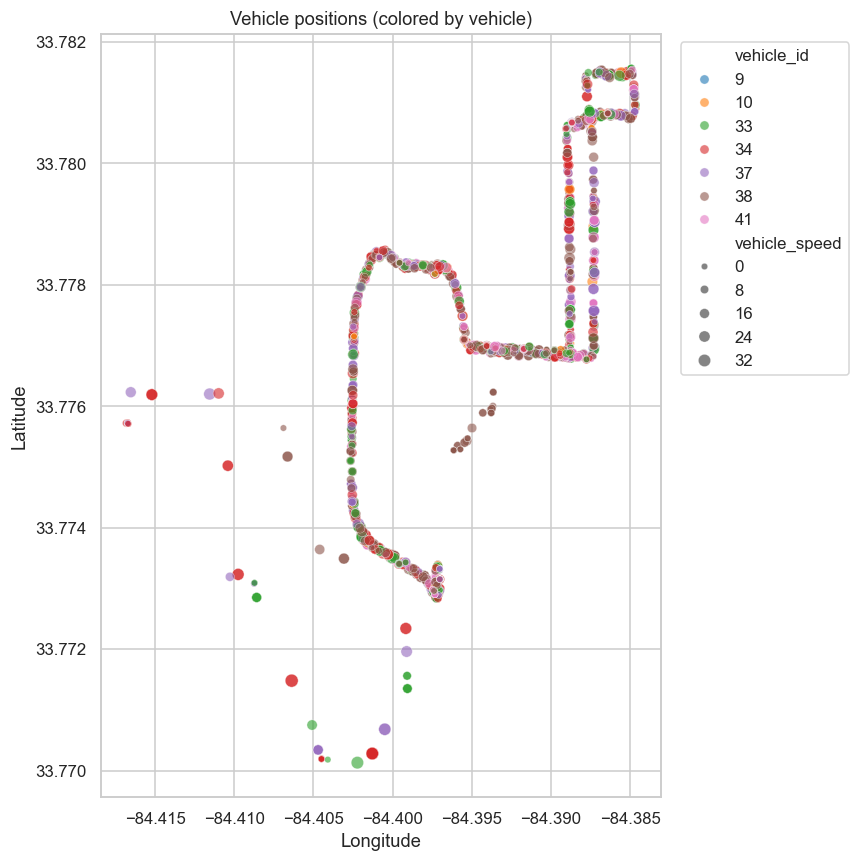

In [16]:
plot_df = df.dropna(subset=["vehicle_lat", "vehicle_lon"]).sample(
    min(len(df), 5000), random_state=42
)

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=plot_df,
    x="vehicle_lon",
    y="vehicle_lat",
    hue="vehicle_id",
    size="vehicle_speed",
    alpha=0.6,
    palette="tab10",
)
plt.title("Vehicle positions (colored by vehicle)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 8. ETA prediction stability

For each (vehicle, stop) pair across multiple snapshots, we track how the ETA changes over time. Stable predictions should decrease roughly linearly as the bus approaches. Large jumps signal instability.

ETA change observations: 60,180

ETA change (minutes) between consecutive snapshots:
count    60180.000
mean         0.000
std          3.965
min        -31.833
25%         -0.483
50%         -0.267
75%          0.000
max         32.533

Snapshots where ETA increased (prediction got worse): 2.1%


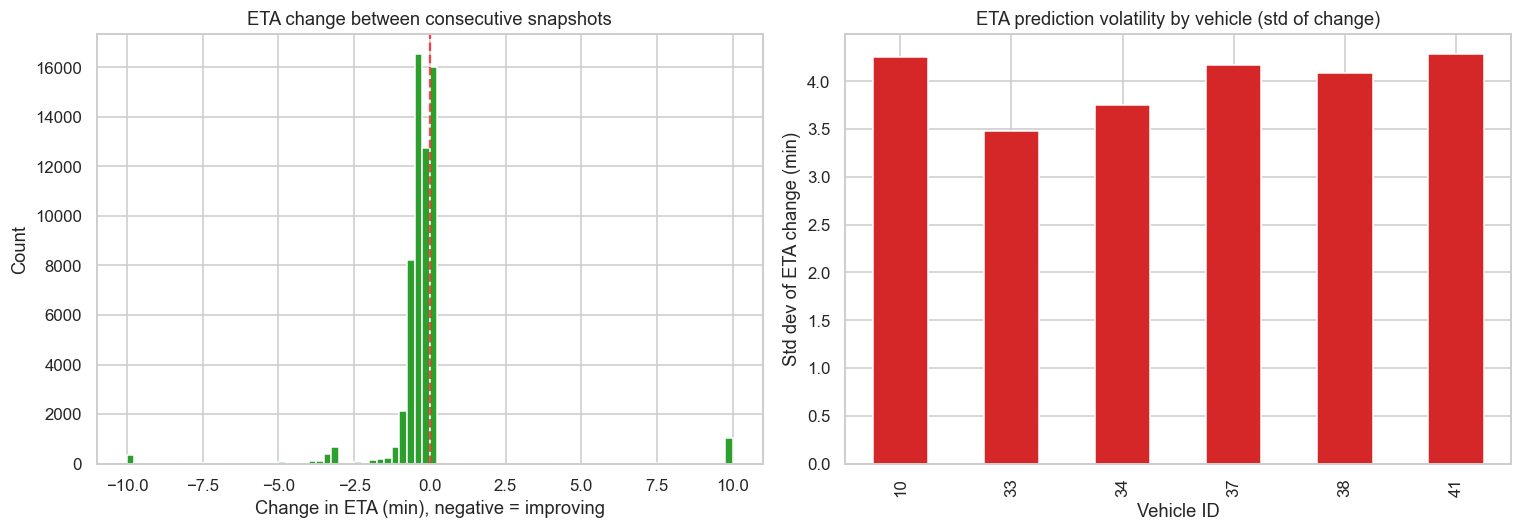

In [17]:
# For each (vehicle, stop), compute how ETA changes between consecutive snapshots
eta_df = (
    df.dropna(subset=["eta_minutes", "route_stop_id"])
    .sort_values(["vehicle_id", "route_stop_id", "snapshot_time"])
    .copy()
)

eta_df["prev_eta"] = eta_df.groupby(["vehicle_id", "route_stop_id"])["eta_minutes"].shift(1)
eta_df["eta_change"] = eta_df["eta_minutes"] - eta_df["prev_eta"]
eta_df = eta_df.dropna(subset=["eta_change"])

print(f"ETA change observations: {len(eta_df):,}")
print()
print("ETA change (minutes) between consecutive snapshots:")
print(eta_df["eta_change"].describe().round(3).to_string())
print()

# Positive eta_change = prediction jumped UP (got worse)
pct_increase = (eta_df["eta_change"] > 0).mean() * 100
print(f"Snapshots where ETA increased (prediction got worse): {pct_increase:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(eta_df["eta_change"].clip(-10, 10), bins=80, color="#2ca02c", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("ETA change between consecutive snapshots")
axes[0].set_xlabel("Change in ETA (min), negative = improving")
axes[0].set_ylabel("Count")

# Per-vehicle stability
vehicle_stability = (
    eta_df.groupby("vehicle_id")["eta_change"]
    .agg(["mean", "std", "size"])
    .round(3)
    .rename(columns={"mean": "avg_change", "std": "std_change", "size": "obs"})
)
vehicle_stability.plot(kind="bar", y="std_change", ax=axes[1], color="#d62728", legend=False)
axes[1].set_title("ETA prediction volatility by vehicle (std of change)")
axes[1].set_xlabel("Vehicle ID")
axes[1].set_ylabel("Std dev of ETA change (min)")

plt.tight_layout()

## 9. Data quality checks

In [18]:
quality_checks = {
    "negative_speed_rows": int((df["vehicle_speed"] < 0).sum()),
    "negative_eta_rows": int((df["eta_minutes"] < 0).sum()),
    "zero_speed_pct": round((df["vehicle_speed"] == 0).mean() * 100, 1),
    "missing_route_stop": int(df["route_stop_id"].isna().sum()),
    "missing_eta": int(df["eta_minutes"].isna().sum()),
    "lat_out_of_range": int(((df["vehicle_lat"] < 33.7) | (df["vehicle_lat"] > 33.85)).sum()),
    "lon_out_of_range": int(((df["vehicle_lon"] < -84.45) | (df["vehicle_lon"] > -84.35)).sum()),
}

pd.Series(quality_checks, name="value").to_frame()

,value
negative_speed_rows,0.0
negative_eta_rows,0.0
zero_speed_pct,45.5
missing_route_stop,3.0
missing_eta,639.0
lat_out_of_range,0.0
lon_out_of_range,0.0


## 10. Key takeaways

**Dataset:**
- ~60k rows after removing duplicates, 3 partial days, 1 route (Gold, route_id=29), 5-7 vehicles, 21 stops.
- No full 24-hour coverage on any day.

**Data quality:**
- 2,600 exact duplicates removed. ~1% of rows missing ETAs.
- No negative speeds or ETAs. Coordinates within expected Atlanta bounds.

**Next steps:**
- Use snapshot frequency profile to filter or impute irregular intervals.
- Per-stop ETA breakdown identifies which stops matter most for delay prediction.
- ETA stability analysis provides a baseline for measuring prediction improvement.
- Weather or traffic incident data could explain delay spikes in the time-series.

---

## 11. Model proposal

### What does the user actually need?

A rider at a stop wants to know: **"How many minutes until my bus arrives, and can I trust that number?"**

A concrete wait time in minutes is far more useful than a binary "delayed or not" or a vague category. "Your bus is ~8 minutes away" is actionable; "your bus is delayed" is not.

| Target option | User value | Verdict |
|---|---|---|
| **Delay in minutes (regression)** | Directly actionable, rider knows whether to wait or walk | **Best choice** |
| Binary (delayed or not) | Loses magnitude: "delayed" could mean 2 min or 20 min | Too coarse |
| Category (small/medium/large) | Slightly better than binary, but arbitrary bins, still not actionable | Marginal gain over binary |

**Recommended target: `eta_minutes`** (or `delay_minutes` once schedule data is available).

We don't have a ground-truth schedule yet, so we define delay as deviation from the rolling median ETA for that stop and hour. This captures "worse than usual" without needing a timetable.

---

### Proposed model: Gradient Boosted Trees (XGBoost / LightGBM)

**What it is:**
An ensemble of small decision trees built sequentially, where each tree corrects the errors of the previous ones. The final prediction is the sum of all trees.

**Why it fits this dataset:**

| Consideration | Why GBTs work here |
|---|---|
| **~60k rows** | Sweet spot for GBTs: enough to learn patterns, fast to train (seconds) |
| **Mixed feature types** | Handles categorical (stop ID, vehicle ID) and continuous (speed, lat/lon) natively, no encoding needed |
| **Non-linear interactions** | Bus delays have complex patterns (e.g., stop 410 only slow at hour 17); trees capture these automatically |
| **Interpretability** | Built-in feature importance + SHAP values explain individual predictions |
| **Low feature count** | ~6 raw features + derived ones; neural nets would overfit here without careful tuning |

**Alternatives considered:**
- *Linear regression*: too rigid for the non-linear speed/stop/hour interactions in this data.
- *Random forest*: similar approach but typically less accurate than boosting on structured tabular data.
- *Neural network (LSTM/transformer)*: overkill at this scale; would need 100x more data to justify the complexity.

---

### Feature set

| Feature | Source | Type | Rationale |
|---|---|---|---|
| `route_stop_id` | raw | categorical | Stops have structurally different ETAs (Section 5) |
| `vehicle_id` | raw | categorical | Some vehicles are consistently slower (Section 4) |
| `snapshot_hour` | derived | ordinal | Strong hour-of-day effect on speed and ETA (Section 6) |
| `day_of_week` | derived | ordinal | Weekday vs. weekend patterns (needs more data to confirm) |
| `vehicle_speed` | raw | continuous | Most direct indicator of current delay |
| `vehicle_lat`, `vehicle_lon` | raw | continuous | Position on route, proxy for distance to stop |
| `eta_change` | derived | continuous | ETA shift since last snapshot, captures prediction instability (Section 8) |
| `stop_median_eta` | derived | continuous | Rolling median ETA for this stop+hour, baseline for deviation |

**Output:** `eta_minutes`, predicted minutes until the bus arrives at the queried stop.

**Future features:** If schedule data becomes available, the target shifts to `delay_minutes = actual_arrival - scheduled_arrival`. Weather and traffic incident data would also add signal.